# Parte 2 &mdash; Trilha A: Fronteiras + Watershed

**Objetivo da entrega.** Manter o *encoder&ndash;decoder* da Parte 1 (a mesma U-Net) e
trocar apenas **o que ele prev&ecirc;**. A apresenta&ccedil;&atilde;o precisa mostrar, com as
**mesmas m&eacute;tricas da Parte 1 lado a lado com a baseline**, por que essa
representa&ccedil;&atilde;o resolve o problema que limiar + componentes conexos n&atilde;o resolve.

## O que a rede prev&ecirc;

| Cabe&ccedil;a | Sa&iacute;da | Alvo | Perda |
|---|---|---|---|
| `semantic` | `[N,3,H,W]` | 0 = fundo, 1 = **interior**, 2 = **fronteira** | CE balanceada **ou** focal (slides 74&ndash;79) |
| `distance` | `[N,1,H,W]` | transformada de dist&acirc;ncia ao fundo, normalizada por inst&acirc;ncia | L1 (slide 80) |

## Decodifica&ccedil;&atilde;o (watershed)

1. **marcadores** = componentes conexos da classe **interior** prevista (n&uacute;cleos
   erodidos &rarr; um marcador por n&uacute;cleo, j&aacute; separados);
2. **relevo** = `-distance` prevista (a &aacute;gua desce dos centros para as fronteiras);
3. **m&aacute;scara** = tudo que n&atilde;o &eacute; fundo (`argmax != 0`);
4. `skimage.segmentation.watershed(relevo, marcadores, mask)` &rarr; uma bacia por n&uacute;cleo.

**Baseline (Parte 1):** a mesma m&aacute;scara de n&atilde;o-fundo &rarr; `scipy.ndimage.label`
(componentes conexos). N&uacute;cleos encostados viram **um** componente.

## Por que isso resolve o fracasso da Parte 1

`label()` funde qualquer foreground que se toque. A classe **fronteira** abre uma
**vala** de largura `~2 * BOUNDARY_WIDTH` entre dois n&uacute;cleos encostados; o watershed
cresce cada interior at&eacute; essa vala e para. **Mesma rede, mesma m&aacute;scara de
foreground &mdash; s&oacute; muda o decodificador.**

## Respostas &agrave;s perguntas do enunciado

* **Como gerar o r&oacute;tulo de fronteira a partir das m&aacute;scaras individuais?** Para cada
  inst&acirc;ncia, transformada de dist&acirc;ncia interna (`EDT`); **interior** = `EDT >
  BOUNDARY_WIDTH`, **fronteira** = o resto da inst&acirc;ncia (a casca). Dois n&uacute;cleos
  encostados ficam separados por uma faixa de fronteira de `~2 * BOUNDARY_WIDTH`.
* **Que espessura?** `BOUNDARY_WIDTH` (em pixels da imagem 128&times;128). Fina demais &rarr; o
  watershed vaza entre n&uacute;cleos encostados; grossa demais &rarr; come o interior de
  n&uacute;cleos pequenos e o marcador some. Come&ccedil;amos em **2**.
* **Como pesar a classe fronteira, que &eacute; minorit&aacute;ria?** Na **perda**, n&atilde;o no
  r&oacute;tulo. `balanced_cross_entropy` usa peso por frequ&ecirc;ncia inversa; `focal_loss`
  usa `gamma` para focar o gradiente nos pixels dif&iacute;ceis (que s&atilde;o a fronteira). A
  c&eacute;lula de diagn&oacute;stico imprime a frequ&ecirc;ncia real das tr&ecirc;s classes.

**Regra de matching (todas as m&eacute;tricas de inst&acirc;ncia):** guloso por IoU decrescente
(`src/nn/metrics.py::match_instances`).

In [24]:
# ============================================================
# IMPORTS
# ============================================================

import sys
import os

sys.path.append(os.path.abspath(".."))

import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split

from PIL import Image
import torchvision.transforms.functional as TF

from src.dataset.bbbc038 import BBBC038Dataset, SegmentationTransform

from src.nn.models import UNet
from src.nn.optimizers import create_optimizer

from src.nn.loss import balanced_cross_entropy, focal_loss, l1_loss

from src.nn.targets import (
    instance_map_to_boundary_targets,
    decode_watershed,
)

from src.nn.metrics import (
    binary_iou_dice,
    instance_scores,
    connected_components,
    count_tp_fp_fn,
    mean_average_precision,
)

In [25]:
# ============================================================
# CONFIGURACOES
# ============================================================

SEED = 67

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# Representacao / perdas
# ------------------------------------------------------------

IMAGE_SIZE      = (128, 128)   # mesmo tamanho da Parte 1
BOUNDARY_WIDTH  = 0.5            # espessura da casca de fronteira (px)
MIN_INST_PIXELS = 4            # instancias que sumiram no resize sao ignoradas

SEMANTIC_LOSS   = "balanced_ce"      # "focal" ou "balanced_ce"
FOCAL_GAMMA     = 2.0          # so usado com SEMANTIC_LOSS="focal"
SEMANTIC_WEIGHT = 1.0
DISTANCE_WEIGHT = 1.0          # peso da regressao L1 do mapa de distancia

# ------------------------------------------------------------
# Decodificacao  (ajuste pelo DIAGNOSTICO antes do eval caro)
# ------------------------------------------------------------

INTERIOR_THRESH = 0.50         # prob minima da classe interior p/ virar marcador
MIN_MARKER_SIZE = 5            # marcadores menores que isso sao ruido

NUM_EPOCHS  = 10
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = ["fundo", "interior", "fronteira"]

Device: cpu


In [26]:
# ============================================================
# MODELO  --  MESMO ENCODER-DECODER DA PARTE 1
# ============================================================
#
# Reaproveitamos os modulos da U-Net de src/nn/models.py (larguras
# 32/64/128, tres skip connections). A UNICA mudanca em relacao a
# Parte 1 e trocar o `final_conv` de 1x1 por DUAS cabecas 1x1.
# ============================================================

class UNetTrilhaA(nn.Module):
    """
    U-Net da Parte 1 com duas cabecas:

        semantic : [N, 3, H, W]  logits  (0=fundo, 1=interior, 2=fronteira)
        distance : [N, 1, H, W]  logit   (sigmoid -> distancia normalizada 0..1)
    """

    def __init__(self):
        super().__init__()

        base = UNet(num_classes=2)   # backbone identico ao da Parte 1

        self.enc1, self.enc2, self.enc3 = base.enc1, base.enc2, base.enc3
        self.pool = base.pool

        self.up3, self.dec3 = base.up3, base.dec3
        self.up2, self.dec2 = base.up2, base.dec2
        self.up1, self.dec1 = base.up1, base.dec1

        # antes: um unico Conv2d(16, num_classes, 1)
        self.semantic_head = nn.Conv2d(16, 3, kernel_size=1)
        self.distance_head = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x); p1 = self.pool(e1)
        e2 = self.enc2(p1); p2 = self.pool(e2)
        e3 = self.enc3(p2); p3 = self.pool(e3)

        d3 = self.dec3(torch.cat([self.up3(p3), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.semantic_head(d1), self.distance_head(d1)

In [27]:
# ============================================================
# HELPERS  (usados no diagnostico, no eval e nas figuras)
# ============================================================

def masks_to_list(instance_map):
    """instance_map [H,W] com ids 0..K  ->  lista de mascaras booleanas."""
    ids = np.unique(instance_map)
    ids = ids[ids > 0]
    return [instance_map == i for i in ids]


def resize_gt(gt_bool, size):
    img = Image.fromarray((gt_bool.astype(np.uint8) * 255))
    img = TF.resize(img, size, interpolation=TF.InterpolationMode.NEAREST)
    return np.array(img) > 0


def watershed_from_outputs(sem_prob, dist_pred,
                           interior_thresh=None, min_marker_size=None):
    """
    sem_prob:  [3,H,W] probabilidades (softmax) fundo/interior/fronteira
    dist_pred: [H,W]   distancia prevista (sigmoid), 0..1

    Devolve o mapa de instancias por watershed.
    """
    if interior_thresh is None:
        interior_thresh = INTERIOR_THRESH
    if min_marker_size is None:
        min_marker_size = MIN_MARKER_SIZE

    interior_mask   = sem_prob[1] > interior_thresh
    foreground_mask = sem_prob.argmax(axis=0) != 0     # nao-fundo

    return decode_watershed(
        interior_mask=interior_mask,
        foreground_mask=foreground_mask,
        landscape=-dist_pred,
        min_marker_size=min_marker_size,
    )


def semantic_from_outputs(sem_prob):
    """foreground = interior + fronteira (tudo que nao e fundo)."""
    fg_prob = sem_prob[1] + sem_prob[2]
    fg_mask = sem_prob.argmax(axis=0) != 0
    return fg_prob, fg_mask

In [28]:
# ============================================================
# ALVOS  +  LOOP DE TREINO  (semantic 3 classes + distancia L1)
# ============================================================

def build_targets(instance_map_batch):
    """
    instance_map_batch: LongTensor [B, H, W]  (0 = fundo, 1..K = instancias)

    Retorna:
        semantic  [B, H, W] long   0=fundo 1=interior 2=fronteira
        distance  [B, H, W] float  distancia ao fundo, normalizada por instancia
    """
    sem, dist = [], []
    for i in range(instance_map_batch.shape[0]):
        s, d = instance_map_to_boundary_targets(
            instance_map_batch[i].detach().cpu().numpy(),
            boundary_width=BOUNDARY_WIDTH,
            min_pixels=MIN_INST_PIXELS,
        )
        sem.append(s)
        dist.append(d)
    return torch.stack(sem), torch.stack(dist)


def semantic_loss(pred_logits, target):
    if SEMANTIC_LOSS == "focal":
        return focal_loss(pred_logits, target, class_weights="balanced", gamma=FOCAL_GAMMA)
    elif SEMANTIC_LOSS == "balanced_ce":
        return balanced_cross_entropy(pred_logits, target)
    raise ValueError(SEMANTIC_LOSS)


def train_epoch(dataloader, model, optimizer, device):

    model.train()
    acc = {"loss": 0.0, "semantic": 0.0, "distance": 0.0}

    for X, instance_map in dataloader:

        X = X.to(device)
        sem_t, dist_t = build_targets(instance_map)
        sem_t, dist_t = sem_t.to(device), dist_t.to(device)

        sem_logits, dist_logits = model(X)
        dist_pred = torch.sigmoid(dist_logits).squeeze(1)

        sem_loss  = semantic_loss(sem_logits, sem_t)
        dist_loss = l1_loss(dist_pred, dist_t)

        loss = SEMANTIC_WEIGHT * sem_loss + DISTANCE_WEIGHT * dist_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        acc["loss"]     += loss.item()
        acc["semantic"] += sem_loss.item()
        acc["distance"] += dist_loss.item()

    n = len(dataloader)
    return {k: v / n for k, v in acc.items()}

In [29]:
# ============================================================
# DADOS  --  MESMO SPLIT DA PARTE 1
# ============================================================
#
# random_split com a MESMA seed e a MESMA proporcao 80/20 usada no
# 1_baseline.ipynb => o conjunto de validacao e IDENTICO ao da baseline,
# entao as metricas sao comparaveis linha a linha.
# ============================================================

train_transform = SegmentationTransform(size=IMAGE_SIZE, augment=True)
eval_transform  = SegmentationTransform(size=IMAGE_SIZE, augment=False)

train_dataset_full = BBBC038Dataset(root="../data/stage1_train", transform=train_transform, mode="instance")
eval_dataset_full  = BBBC038Dataset(root="../data/stage1_train", transform=eval_transform,  mode="instance")

n_total = len(train_dataset_full)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

train_split, _ = random_split(train_dataset_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
_, val_split   = random_split(eval_dataset_full,  [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

print(f"treino: {len(train_split)}  |  validacao: {len(val_split)}")

batch_size = 32
train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True,  num_workers=0)
eval_loader  = DataLoader(val_split,   batch_size=batch_size, shuffle=False, num_workers=0)

treino: 536  |  validacao: 134


In [30]:
# ============================================================
# TREINO
# ============================================================

model = UNetTrilhaA().to(device)
optimizer = create_optimizer("Adam", model, lr=1e-3)

history = []
for epoch in range(NUM_EPOCHS):
    logs = train_epoch(train_loader, model, optimizer, device)
    history.append(logs)
    print(
        f"Epoch {epoch + 1:2d}/{NUM_EPOCHS} | loss {logs['loss']:.4f} | "
        f"semantic ({SEMANTIC_LOSS}) {logs['semantic']:.4f} | distance (L1) {logs['distance']:.4f}"
    )

Epoch  1/10 | loss 1.3663 | semantic (balanced_ce) 0.9694 | distance (L1) 0.3969
Epoch  2/10 | loss 1.0862 | semantic (balanced_ce) 0.7252 | distance (L1) 0.3610
Epoch  3/10 | loss 0.9440 | semantic (balanced_ce) 0.6104 | distance (L1) 0.3336
Epoch  4/10 | loss 0.8339 | semantic (balanced_ce) 0.5275 | distance (L1) 0.3064
Epoch  5/10 | loss 0.7455 | semantic (balanced_ce) 0.4623 | distance (L1) 0.2832
Epoch  6/10 | loss 0.6460 | semantic (balanced_ce) 0.3958 | distance (L1) 0.2502
Epoch  7/10 | loss 0.5700 | semantic (balanced_ce) 0.3459 | distance (L1) 0.2242
Epoch  8/10 | loss 0.5039 | semantic (balanced_ce) 0.3067 | distance (L1) 0.1972
Epoch  9/10 | loss 0.4399 | semantic (balanced_ce) 0.2666 | distance (L1) 0.1733
Epoch 10/10 | loss 0.3950 | semantic (balanced_ce) 0.2435 | distance (L1) 0.1514


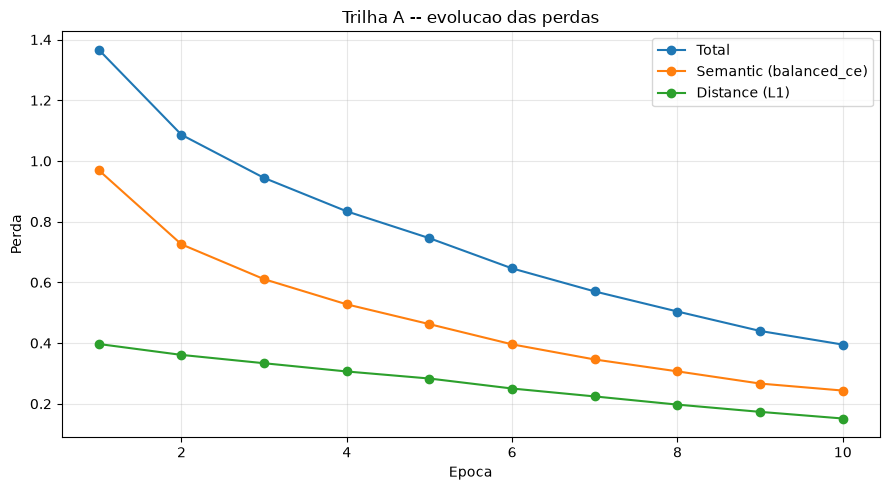

In [31]:
# ============================================================
# CURVAS DE PERDA
# ============================================================

ep = np.arange(1, NUM_EPOCHS + 1)
plt.figure(figsize=(9, 5))
for key, label in [("loss", "Total"),
                   ("semantic", f"Semantic ({SEMANTIC_LOSS})"),
                   ("distance", "Distance (L1)")]:
    plt.plot(ep, [h[key] for h in history], marker="o", label=label)
plt.xlabel("Epoca"); plt.ylabel("Perda"); plt.title("Trilha A -- evolucao das perdas")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Diagn&oacute;stico das cabe&ccedil;as

Antes de comparar decodificadores, confirmamos que:

* a classe **fronteira** (minorit&aacute;ria) est&aacute; sendo aprendida &mdash; olhe o **recall da
  fronteira**, n&atilde;o a acur&aacute;cia global (que o fundo infla);
* o n&uacute;mero de **marcadores** (interiores conexos) bate com o n&uacute;mero de n&uacute;cleos;
* o mapa de **dist&acirc;ncia** tem picos nos centros.

Se o recall da fronteira estiver baixo, aumente `SEMANTIC_WEIGHT`, troque para
`focal` com `gamma` maior, ou engrosse `BOUNDARY_WIDTH`. Se houver marcadores
demais (super-segmenta&ccedil;&atilde;o), suba `INTERIOR_THRESH` ou `MIN_MARKER_SIZE`.

frequencia das classes (GT):
   fundo    : 0.866
   interior : 0.134
   fronteira: 0.000

qualidade por classe (pred vs GT):
   fundo    : recall 0.941 | precisao 0.996
   interior : recall 0.977 | precisao 0.720
   fronteira: recall 0.000 | precisao 0.000

instancias watershed / imagem -> min 3 | mediana 20 | max 101
nucleos verdadeiros / imagem -> mediana 27


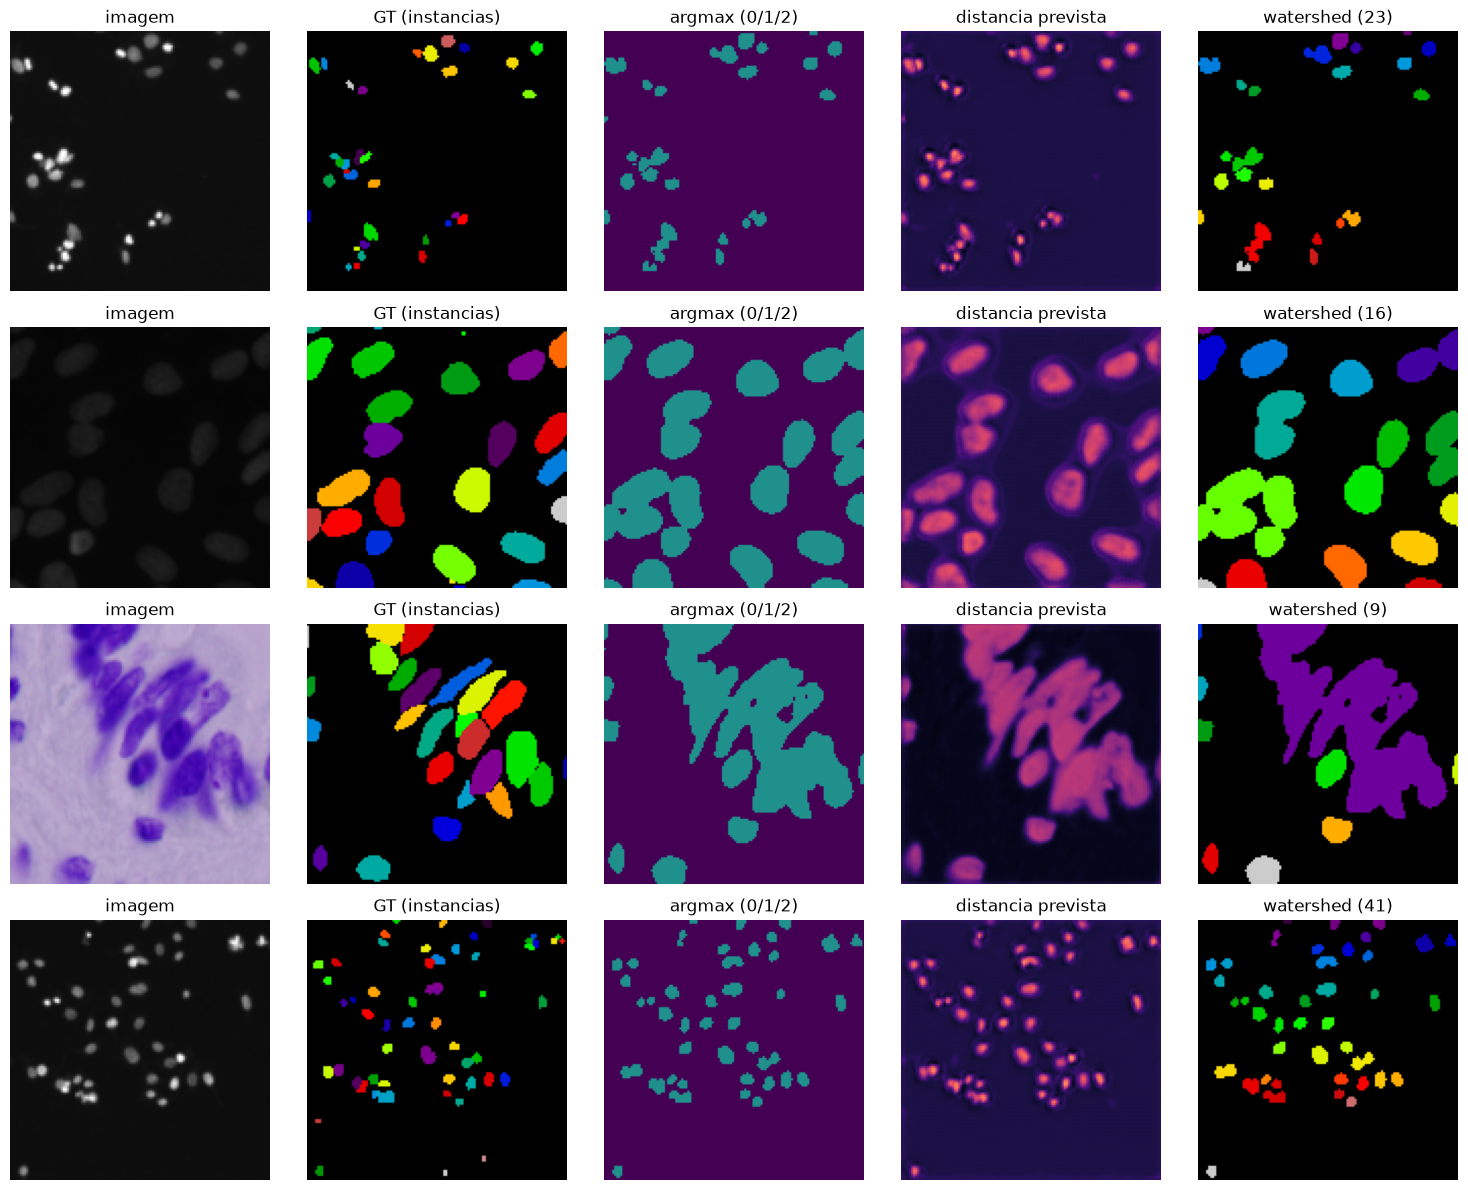

In [32]:
# ============================================================
# DIAGNOSTICO DAS CABECAS
# ============================================================

model.eval()
Xb, Yb = next(iter(eval_loader))
with torch.no_grad():
    sem_l, dist_l = model(Xb.to(device))

sem_prob  = torch.softmax(sem_l, dim=1).cpu().numpy()          # [B,3,H,W]
dist_pred = torch.sigmoid(dist_l).squeeze(1).cpu().numpy()     # [B,H,W]
sem_gt, dist_gt = build_targets(Yb)
sem_gt = sem_gt.numpy()
pred_cls = sem_prob.argmax(axis=1)

# frequencia das 3 classes (mostra o quanto a fronteira e minoritaria)
freq = np.bincount(sem_gt.reshape(-1), minlength=3) / sem_gt.size
print("frequencia das classes (GT):")
for name, f in zip(CLASS_NAMES, freq):
    print(f"   {name:9}: {f:.3f}")

# recall / precisao por classe
print("\nqualidade por classe (pred vs GT):")
for c, name in enumerate(CLASS_NAMES):
    tp = np.sum((pred_cls == c) & (sem_gt == c))
    fn = np.sum((pred_cls != c) & (sem_gt == c))
    fp = np.sum((pred_cls == c) & (sem_gt != c))
    rec  = tp / (tp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    print(f"   {name:9}: recall {rec:.3f} | precisao {prec:.3f}")

# marcadores vs nucleos
markers_per_img, nuclei_per_img = [], []
for i in range(Xb.shape[0]):
    lab = watershed_from_outputs(sem_prob[i], dist_pred[i])
    markers_per_img.append(len(masks_to_list(lab)))
    nuclei_per_img.append(len(np.unique(Yb[i].numpy())) - 1)
print(f"\ninstancias watershed / imagem -> min {min(markers_per_img)} | "
      f"mediana {int(np.median(markers_per_img))} | max {max(markers_per_img)}")
print(f"nucleos verdadeiros / imagem -> mediana {int(np.median(nuclei_per_img))}")

n = min(4, Xb.shape[0])
fig, ax = plt.subplots(n, 5, figsize=(15, 3 * n))
for i in range(n):
    lab = watershed_from_outputs(sem_prob[i], dist_pred[i])
    ax[i, 0].imshow(Xb[i].permute(1, 2, 0).numpy());        ax[i, 0].set_title("imagem")
    ax[i, 1].imshow(Yb[i], cmap="nipy_spectral");           ax[i, 1].set_title("GT (instancias)")
    ax[i, 2].imshow(pred_cls[i], vmin=0, vmax=2, cmap="viridis"); ax[i, 2].set_title("argmax (0/1/2)")
    ax[i, 3].imshow(dist_pred[i], vmin=0, vmax=1, cmap="magma"); ax[i, 3].set_title("distancia prevista")
    ax[i, 4].imshow(lab, cmap="nipy_spectral");             ax[i, 4].set_title(f"watershed ({len(masks_to_list(lab))})")
    for a in ax[i]:
        a.axis("off")
plt.tight_layout(); plt.show()

## Avalia&ccedil;&atilde;o: baseline vs Trilha A na mesma rede

`evaluate` roda **uma vez** por imagem de valida&ccedil;&atilde;o e decodifica de **duas**
formas a partir da **mesma** sa&iacute;da da rede:

* `baseline`  &mdash; m&aacute;scara n&atilde;o-fundo + componentes conexos (m&eacute;todo da Parte 1);
* `trilha_a`  &mdash; watershed com os interiores como marcadores.

M&eacute;tricas da Parte 1: **IoU** e **Dice** sem&acirc;nticos (fundo vs. objeto, id&ecirc;nticos
nas duas colunas), **AP por limiar de IoU 0,50&ndash;0,95** + **mAP**, **TP/FP/FN**, e
**erro absoluto de contagem** por imagem. O *score* de cada inst&acirc;ncia &eacute; a
probabilidade m&eacute;dia de n&atilde;o-fundo dentro dela &mdash; a mesma regra nos dois
decodificadores.

In [33]:
# ============================================================
# EVALUATE  --  baseline (nao-fundo + CC)  vs  trilha A (watershed)
# ============================================================

@torch.no_grad()
def evaluate(model, dataloader, base_dataset, device):
    model.eval()
    subset_indices = dataloader.dataset.indices          # random_split -> Subset
    pos = 0

    methods = ("baseline", "trilha_a")
    predictions = {m: [] for m in methods}
    scores      = {m: [] for m in methods}
    count_err   = {m: [] for m in methods}
    ground_truths, gt_counts = [], []
    sem_iou, sem_dice = [], []

    for X, _ in dataloader:
        X = X.to(device)
        sem_l, dist_l = model(X)
        sem_prob  = torch.softmax(sem_l, dim=1).cpu().numpy()
        dist_pred = torch.sigmoid(dist_l).squeeze(1).cpu().numpy()

        for i in range(X.shape[0]):
            fg_prob, fg_mask = semantic_from_outputs(sem_prob[i])
            size = fg_mask.shape

            # ---------- GROUND TRUTH ----------
            sample = base_dataset.samples[int(subset_indices[pos])]
            pos += 1
            gt = [resize_gt(g, size) for g in base_dataset._load_instance_masks(sample["masks"])]
            gt_union = np.zeros(size, dtype=bool)
            for g in gt:
                gt_union |= g
            ground_truths.append(gt)
            gt_counts.append(len(gt))

            iou, dice = binary_iou_dice(fg_mask, gt_union)
            sem_iou.append(iou); sem_dice.append(dice)

            # ---------- BASELINE ----------
            base_inst = connected_components(fg_mask)

            # ---------- TRILHA A ----------
            lab = watershed_from_outputs(sem_prob[i], dist_pred[i])
            ta_inst = masks_to_list(lab)

            for name, inst in [("baseline", base_inst), ("trilha_a", ta_inst)]:
                predictions[name].append(inst)
                scores[name].append(instance_scores(fg_prob, inst))
                count_err[name].append({"true": len(gt), "pred": len(inst),
                                        "error": abs(len(inst) - len(gt))})

    semantic = {"iou": float(np.mean(sem_iou)), "dice": float(np.mean(sem_dice))}
    return predictions, scores, count_err, ground_truths, gt_counts, semantic

In [34]:
# ============================================================
# RODA A AVALIACAO
# ============================================================

predictions, scores, count_err, ground_truths, gt_counts, semantic = evaluate(
    model, eval_loader, eval_dataset_full, device
)

print(f"Semantico (fundo vs. objeto)  ->  IoU {semantic['iou']:.4f} | Dice {semantic['dice']:.4f}")
print(f"Imagens avaliadas: {len(ground_truths)} | objetos GT: {sum(gt_counts)}")
print("instancias decodificadas -> baseline:",
      sum(len(p) for p in predictions["baseline"]),
      "| trilha A:", sum(len(p) for p in predictions["trilha_a"]))

Semantico (fundo vs. objeto)  ->  IoU 0.6776 | Dice 0.7963
Imagens avaliadas: 134 | objetos GT: 6130
instancias decodificadas -> baseline: 3589 | trilha A: 3522


In [35]:
# ============================================================
# METRICAS DE INSTANCIA  --  BASELINE  vs  TRILHA A
# ============================================================

IOU_THRESHOLDS = np.arange(0.50, 0.951, 0.05)
per_method = {}

for method in ("baseline", "trilha_a"):
    map_value, aps = mean_average_precision(
        predictions[method], ground_truths, scores[method], thresholds=IOU_THRESHOLDS
    )
    tp50, fp50, fn50 = count_tp_fp_fn(predictions[method], ground_truths, 0.50)
    mean_count = float(np.mean([c["error"] for c in count_err[method]]))

    per_method[method] = {
        "IoU (semantico)":        semantic["iou"],
        "Dice (semantico)":       semantic["dice"],
        "mAP@[.50:.95]":          map_value,
        "AP@0.50":                aps[0.5],
        "AP@0.75":                aps[0.75],
        "AP@0.90":                aps[0.9],
        "TP@0.50":                tp50,
        "FP@0.50":                fp50,
        "FN@0.50":                fn50,
        "erro medio de contagem": mean_count,
    }

comparison = pd.DataFrame(per_method).rename(
    columns={"baseline": "Baseline (nao-fundo + CC)", "trilha_a": "Trilha A (watershed)"}
)

baseline_json = os.path.join(RESULTS_DIR, "1_baseline.json")   # opcional: U-Net semantica da Parte 1
if os.path.exists(baseline_json):
    with open(baseline_json) as fh:
        comparison["Parte 1 (U-Net semantica)"] = pd.Series(json.load(fh))

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
comparison

,Baseline (nao-fundo + CC),Trilha A (watershed),Parte 1 (U-Net semantica)
IoU (semantico),0.6776,0.6776,0.6517
Dice (semantico),0.7963,0.7963,0.7714
mAP@[.50:.95],0.1207,0.1287,0.1659
AP@0.50,0.3067,0.3286,0.3731
AP@0.75,0.0728,0.0769,0.1259
AP@0.90,0.0011,0.0011,0.0020
TP@0.50,2410.0000,2555.0000,2783.0000
FP@0.50,1179.0000,967.0000,1434.0000
FN@0.50,3720.0000,3575.0000,3347.0000
erro medio de contagem,20.0224,20.0746,18.9030


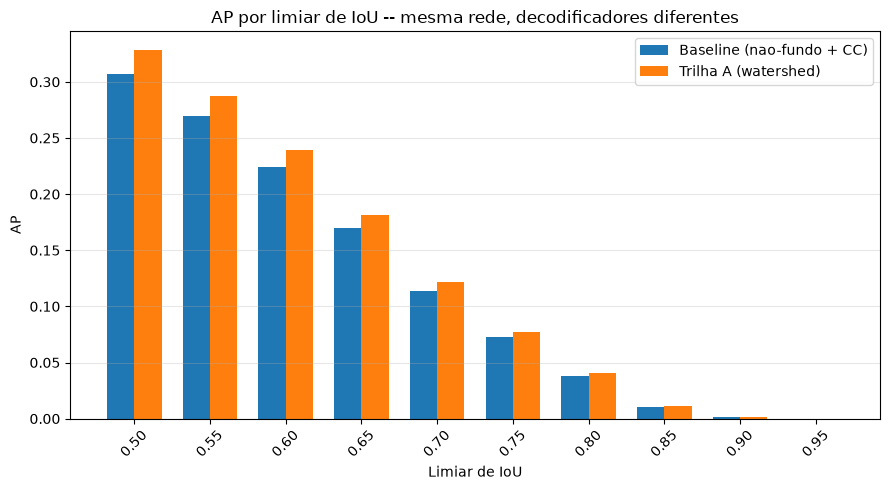

In [36]:
# ============================================================
# AP  x  LIMIAR DE IoU   (baseline  vs  trilha A, lado a lado)
# ============================================================

_, aps_base = mean_average_precision(predictions["baseline"], ground_truths, scores["baseline"], thresholds=IOU_THRESHOLDS)
_, aps_ta   = mean_average_precision(predictions["trilha_a"], ground_truths, scores["trilha_a"], thresholds=IOU_THRESHOLDS)

x = np.array(sorted(aps_base)); w = 0.018
plt.figure(figsize=(9, 5))
plt.bar(x - w/2, [aps_base[k] for k in x], width=w, label="Baseline (nao-fundo + CC)")
plt.bar(x + w/2, [aps_ta[k]   for k in x], width=w, label="Trilha A (watershed)")
plt.xlabel("Limiar de IoU"); plt.ylabel("AP")
plt.title("AP por limiar de IoU -- mesma rede, decodificadores diferentes")
plt.xticks(x, [f"{k:.2f}" for k in x], rotation=45)
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

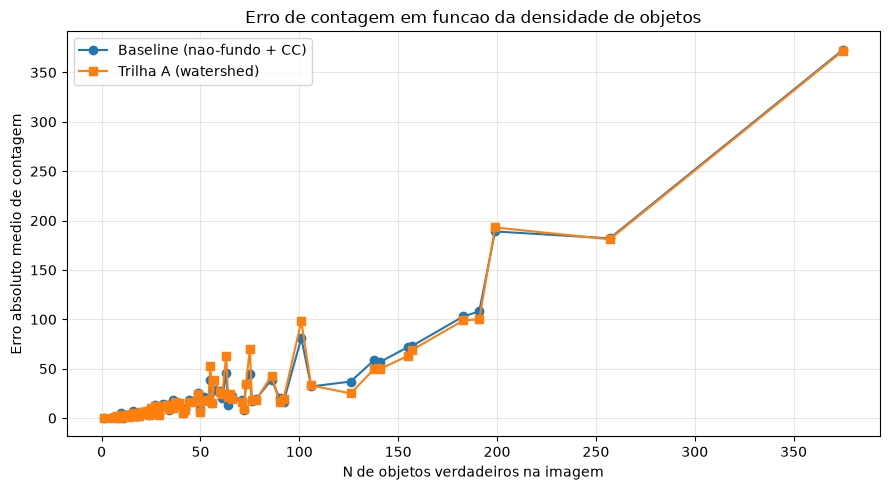

erro medio (baseline)   20.0224
erro medio (trilha A)   20.0746
dtype: float64


In [37]:
# ============================================================
# QUANTIFICANDO O FRACASSO  --  erro de contagem  x  densidade
# ============================================================
#
# Leitura da Parte 1: o erro da baseline cresce com o n de nucleos
# (mais nucleos => mais bordas encostadas => mais fusoes por CC).
# A Trilha A deve achatar essa curva.
# ============================================================

df = pd.DataFrame({
    "true":         gt_counts,
    "err_baseline": [c["error"] for c in count_err["baseline"]],
    "err_trilha_a": [c["error"] for c in count_err["trilha_a"]],
})
g = df.groupby("true").mean()

plt.figure(figsize=(9, 5))
plt.plot(g.index, g["err_baseline"], marker="o", label="Baseline (nao-fundo + CC)")
plt.plot(g.index, g["err_trilha_a"], marker="s", label="Trilha A (watershed)")
plt.xlabel("N de objetos verdadeiros na imagem")
plt.ylabel("Erro absoluto medio de contagem")
plt.title("Erro de contagem em funcao da densidade de objetos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(df[["err_baseline", "err_trilha_a"]].mean().rename(
    {"err_baseline": "erro medio (baseline)", "err_trilha_a": "erro medio (trilha A)"}))

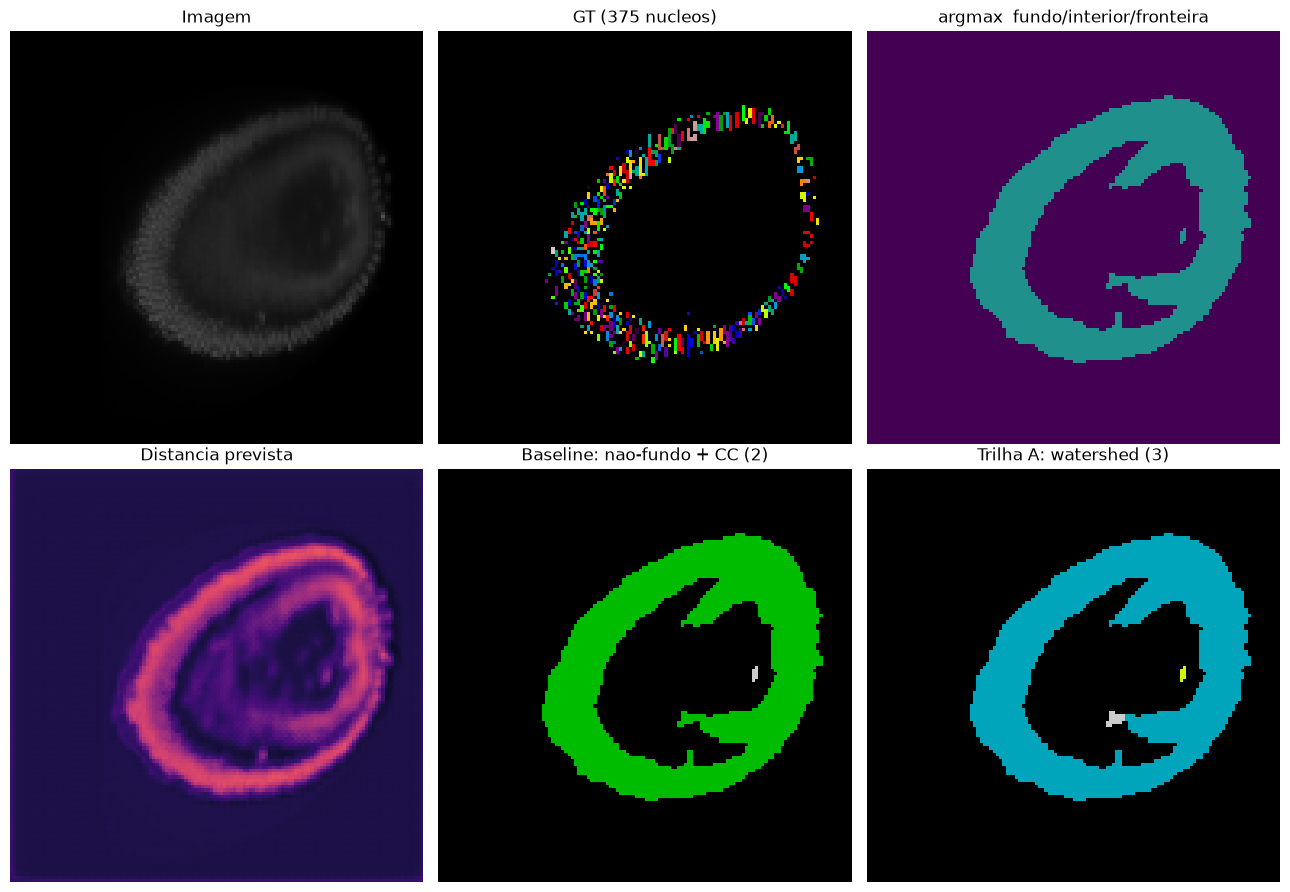

In [38]:
# ============================================================
# PAINEL QUALITATIVO  --  onde a baseline funde e a Trilha A separa
# ============================================================

model.eval()
worst = int(np.argmax(gt_counts))                 # imagem de val mais densa

flat = [X[j] for X, _ in eval_loader for j in range(X.shape[0])]
img = flat[worst].unsqueeze(0).to(device)
with torch.no_grad():
    sem_l, dist_l = model(img)

sem_prob  = torch.softmax(sem_l, dim=1)[0].cpu().numpy()
dist_pred = torch.sigmoid(dist_l)[0, 0].cpu().numpy()
_, fg = semantic_from_outputs(sem_prob)

base_map = np.zeros(fg.shape, dtype=int)
for k, mk in enumerate(connected_components(fg), start=1):
    base_map[mk] = k

ta_map = watershed_from_outputs(sem_prob, dist_pred)

gt_map = np.zeros(fg.shape, dtype=int)
for k, gk in enumerate(ground_truths[worst], start=1):
    gt_map[gk] = k

fig, ax = plt.subplots(2, 3, figsize=(13, 9))
ax[0, 0].imshow(flat[worst].permute(1, 2, 0).numpy()); ax[0, 0].set_title("Imagem")
ax[0, 1].imshow(gt_map, cmap="nipy_spectral");         ax[0, 1].set_title(f"GT ({len(ground_truths[worst])} nucleos)")
ax[0, 2].imshow(sem_prob.argmax(axis=0), vmin=0, vmax=2, cmap="viridis"); ax[0, 2].set_title("argmax  fundo/interior/fronteira")
ax[1, 0].imshow(dist_pred, vmin=0, vmax=1, cmap="magma"); ax[1, 0].set_title("Distancia prevista")
ax[1, 1].imshow(base_map, cmap="nipy_spectral");       ax[1, 1].set_title(f"Baseline: nao-fundo + CC ({base_map.max()})")
ax[1, 2].imshow(ta_map, cmap="nipy_spectral");         ax[1, 2].set_title(f"Trilha A: watershed ({int(ta_map.max())})")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout(); plt.show()

In [39]:
# ============================================================
# SALVA OS NUMEROS DA TRILHA A  (Partes 3-6 e apresentacao)
# ============================================================

def _clean(d):
    return {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in d.items()}

payload = _clean(per_method["trilha_a"])
payload["baseline_mesma_rede"] = _clean(per_method["baseline"])
payload["hiperparametros"] = {
    "boundary_width": BOUNDARY_WIDTH,
    "semantic_loss": SEMANTIC_LOSS,
    "focal_gamma": FOCAL_GAMMA,
    "distance_weight": DISTANCE_WEIGHT,
    "interior_thresh": INTERIOR_THRESH,
    "min_marker_size": MIN_MARKER_SIZE,
    "epochs": NUM_EPOCHS,
}

with open(os.path.join(RESULTS_DIR, f"2_trilha_a_{SEMANTIC_LOSS}.json"), "w") as fh:
    json.dump(payload, fh, indent=2)
print(json.dumps(payload, indent=2))

{
  "IoU (semantico)": 0.6775836739581866,
  "Dice (semantico)": 0.7962606854981127,
  "mAP@[.50:.95]": 0.12872551877306096,
  "AP@0.50": 0.32856065087964104,
  "AP@0.75": 0.07685139694170809,
  "AP@0.90": 0.0010608326688904528,
  "TP@0.50": 2555.0,
  "FP@0.50": 967.0,
  "FN@0.50": 3575.0,
  "erro medio de contagem": 20.074626865671643,
  "baseline_mesma_rede": {
    "IoU (semantico)": 0.6775836739581866,
    "Dice (semantico)": 0.7962606854981127,
    "mAP@[.50:.95]": 0.12068276759200702,
    "AP@0.50": 0.306700913155741,
    "AP@0.75": 0.07280305630497018,
    "AP@0.90": 0.0011123401189911636,
    "TP@0.50": 2410.0,
    "FP@0.50": 1179.0,
    "FN@0.50": 3720.0,
    "erro medio de contagem": 20.02238805970149
  },
  "hiperparametros": {
    "boundary_width": 0.5,
    "semantic_loss": "balanced_ce",
    "focal_gamma": 2.0,
    "distance_weight": 1.0,
    "interior_thresh": 0.5,
    "min_marker_size": 5,
    "epochs": 10
  }
}


## Conclus&atilde;o &mdash; roteiro da apresenta&ccedil;&atilde;o

* **Mesmo backbone da Parte 1.** S&oacute; trocamos `final_conv` por duas cabe&ccedil;as 1&times;1
  (3 classes sem&acirc;nticas + dist&acirc;ncia). Nenhum detector de regi&atilde;o.
* **A compara&ccedil;&atilde;o &eacute; justa por constru&ccedil;&atilde;o.** As duas colunas usam a mesma rede
  e a mesma m&aacute;scara de n&atilde;o-fundo &mdash; IoU/Dice sem&acirc;nticos id&ecirc;nticos. S&oacute; muda o
  decodificador (componentes conexos &rarr; watershed).
* **O ganho aparece onde a Parte 1 falha.** A curva erro-de-contagem &times; densidade
  da baseline sobe com o n&uacute;mero de n&uacute;cleos; a da Trilha A fica mais plana, e o
  mAP@[.50:.95] sobe junto.
* **Por qu&ecirc;.** A classe **fronteira** abre uma vala entre n&uacute;cleos encostados, e o
  watershed usa os **interiores erodidos** como marcadores separados: cada n&uacute;cleo
  cresce at&eacute; a vala e para, em vez de virar um &uacute;nico componente.
* **O que sintoniza o m&eacute;todo:** `BOUNDARY_WIDTH` (vala fina demais vaza, grossa
  demais come n&uacute;cleos pequenos) e o peso da classe fronteira na perda
  (`balanced_ce` vs `focal`+`gamma`). S&atilde;o os dois eixos da Parte 3.
* **Limita&ccedil;&otilde;es (Partes 3&ndash;5):** n&uacute;cleo aninhado &mdash; a fronteira do interno &eacute;
  interna ao externo, e o watershed tende a n&atilde;o separar; n&uacute;cleos menores que
  `2 * BOUNDARY_WIDTH` perdem o marcador; erro do `INTERIOR_THRESH` vira erro de
  contagem direto.